# AI Study Assistant - Drowsiness Detection System

## Complete Implementation with Advanced Models & Reinforcement Learning

This notebook implements:
- Advanced deep learning models (EfficientNet, MobileNet, ResNet, InceptionV3)
- Hyperparameter grid search for optimal training
- User feedback mechanism for continuous learning
- Personalized models for each student
- Reinforcement learning from user corrections

**Choose Path:**
- **Quick Start (15 mins)**: Skip hyperparameter tuning, train with defaults
- **Full Grid Search (1-2 hrs)**: Test all hyperparameter combinations

## Step 1: Imports & Configuration

In [1]:
import numpy as np
import os
import json
import pandas as pd
import time
from datetime import datetime
from itertools import product

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Resizing, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import EfficientNetB0, MobileNetV3Small, ResNet50, InceptionV3
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

import matplotlib.pyplot as plt
import pickle

# Configuration
BASE_MODEL_PATH = "study_assistant_model.h5"
USER_MODELS_DIR = "user_models"
FEEDBACK_LOG_DIR = "feedback_logs"
CONFIDENCE_THRESHOLD = 0.6

# Create directories
os.makedirs(USER_MODELS_DIR, exist_ok=True)
os.makedirs(FEEDBACK_LOG_DIR, exist_ok=True)

print("✅ All imports successful!")
print(f"✅ Directories created: {USER_MODELS_DIR}, {FEEDBACK_LOG_DIR}")

✅ All imports successful!
✅ Directories created: user_models, feedback_logs


## Step 2: Advanced Model Builders

In [2]:
def build_efficientnet_model(input_shape=(224, 224, 3), num_classes=3):
    """
    EfficientNet - Best balance of accuracy and efficiency
    - Excellent for production/real-time applications
    - Pre-trained on ImageNet
    """
    try:
        base_model = EfficientNetB0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
    except ValueError:
        # Fallback: train without pre-trained weights if loading fails
        print("⚠️  Could not load pre-trained weights, training from scratch...")
        base_model = EfficientNetB0(
            input_shape=input_shape,
            include_top=False,
            weights=None
        )
    
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    print("✅ EfficientNetB0 loaded")
    return model


def build_mobilenet_model(input_shape=(224, 224, 3), num_classes=3):
    """
    MobileNetV3 - Lightweight, fastest inference
    - Best for mobile/edge devices
    - Real-time processing
    """
    try:
        base_model = MobileNetV3Small(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
    except ValueError:
        print("⚠️  Could not load pre-trained weights, training from scratch...")
        base_model = MobileNetV3Small(
            input_shape=input_shape,
            include_top=False,
            weights=None
        )
    
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    print("✅ MobileNetV3Small loaded")
    return model


def build_resnet_model(input_shape=(224, 224, 3), num_classes=3):
    """
    ResNet50 - Strong baseline, proven architecture
    - Good balance of performance and training time
    - Good for transfer learning
    """
    try:
        base_model = ResNet50(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
    except ValueError:
        print("⚠️  Could not load pre-trained weights, training from scratch...")
        base_model = ResNet50(
            input_shape=input_shape,
            include_top=False,
            weights=None
        )
    
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    print("✅ ResNet50 loaded")
    return model


def build_inception_model(input_shape=(224, 224, 3), num_classes=3):
    """
    InceptionV3 - Powerful feature extraction
    - Excellent accuracy
    - Good for complex feature learning
    """
    try:
        base_model = InceptionV3(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
    except ValueError:
        print("⚠️  Could not load pre-trained weights, training from scratch...")
        base_model = InceptionV3(
            input_shape=input_shape,
            include_top=False,
            weights=None
        )
    
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    print("✅ InceptionV3 loaded")
    return model


# Model factory
MODEL_BUILDERS = {
    'efficientnet': build_efficientnet_model,
    'mobilenet': build_mobilenet_model,
    'resnet': build_resnet_model,
    'inception': build_inception_model,
}

print("✅ All model builders initialized!")

✅ All model builders initialized!


## Step 3: Hyperparameter Tuning System

In [3]:
class HyperparameterTuner:
    """Grid search for optimal hyperparameters"""
    
    def __init__(self, train_data, test_data, base_model_dir="hyperparameter_models"):
        self.train_data = train_data
        self.test_data = test_data
        self.base_model_dir = base_model_dir
        self.results = []
        os.makedirs(base_model_dir, exist_ok=True)
    
    def get_optimizer(self, optimizer_name, learning_rate):
        """Get optimizer with specified learning rate"""
        if optimizer_name == 'adam':
            return Adam(learning_rate=learning_rate)
        elif optimizer_name == 'sgd':
            return SGD(learning_rate=learning_rate)
        elif optimizer_name == 'rmsprop':
            return RMSprop(learning_rate=learning_rate)
        return Adam(learning_rate=learning_rate)
    
    def train_and_evaluate(self, model, hyperparams, combine_id):
        """Train model with given hyperparameters and evaluate"""
        print(f"\n{'='*70}")
        print(f"Testing Combination #{combine_id}")
        print(f"{'='*70}")
        print(f"Hyperparameters: {hyperparams}")
        
        start_time = time.time()
        
        try:
            learning_rate = hyperparams['learning_rate']
            batch_size = hyperparams['batch_size']
            epochs = hyperparams['epochs']
            optimizer_name = hyperparams['optimizer']
            
            optimizer = self.get_optimizer(optimizer_name, learning_rate)
            model.compile(
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )
            
            class_weight = {0: 1.0, 1: 2.0, 2: 3.0}
            
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=2,
                restore_best_weights=True
            )
            
            history = model.fit(
                self.train_data,
                validation_data=self.test_data,
                epochs=epochs,
                batch_size=batch_size,
                class_weight=class_weight,
                callbacks=[early_stop],
                verbose=1
            )
            
            val_loss, val_accuracy = model.evaluate(self.test_data, verbose=0)
            train_loss, train_accuracy = model.evaluate(self.train_data, verbose=0)
            elapsed_time = time.time() - start_time
            
            result = {
                'combination_id': combine_id,
                'learning_rate': learning_rate,
                'batch_size': batch_size,
                'epochs': epochs,
                'optimizer': optimizer_name,
                'train_accuracy': train_accuracy,
                'val_accuracy': val_accuracy,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'time_seconds': elapsed_time,
                'status': 'success'
            }
            
            self.results.append(result)
            
            print(f"\n✅ Training completed!")
            print(f"   Train Accuracy: {train_accuracy:.4f}")
            print(f"   Val Accuracy: {val_accuracy:.4f}")
            print(f"   Time: {elapsed_time:.1f}s")
            
            return result
        
        except Exception as e:
            elapsed_time = time.time() - start_time
            result = {
                'combination_id': combine_id,
                'learning_rate': hyperparams.get('learning_rate'),
                'batch_size': hyperparams.get('batch_size'),
                'epochs': hyperparams.get('epochs'),
                'optimizer': hyperparams.get('optimizer'),
                'train_accuracy': None,
                'val_accuracy': None,
                'train_loss': None,
                'val_loss': None,
                'time_seconds': elapsed_time,
                'status': f'failed: {str(e)}'
            }
            self.results.append(result)
            print(f"\n❌ Training failed: {str(e)}")
            return result
    
    def grid_search(self, model_builder, hyperparameter_grid):
        """Run grid search over all hyperparameter combinations"""
        param_names = list(hyperparameter_grid.keys())
        param_values = list(hyperparameter_grid.values())
        combinations = list(product(*param_values))
        
        total_combinations = len(combinations)
        print(f"\n{'='*70}")
        print(f"🔍 STARTING GRID SEARCH")
        print(f"{'='*70}")
        print(f"Total combinations to test: {total_combinations}")
        print(f"Parameters: {param_names}")
        
        for idx, combo_values in enumerate(combinations, 1):
            hyperparams = dict(zip(param_names, combo_values))
            model = model_builder()
            self.train_and_evaluate(model, hyperparams, idx)
            print(f"\nProgress: {idx}/{total_combinations}")
        
        return self.get_results_dataframe()
    
    def get_results_dataframe(self):
        """Convert results to pandas dataframe"""
        df = pd.DataFrame(self.results)
        return df.sort_values('val_accuracy', ascending=False)
    
    def get_best_combination(self):
        """Get best hyperparameter combination"""
        if not self.results:
            return None
        
        df = self.get_results_dataframe()
        best = df.iloc[0]
        
        print(f"\n{'='*70}")
        print(f"🏆 BEST COMBINATION FOUND")
        print(f"{'='*70}")
        print(f"Combination ID: {best['combination_id']}")
        print(f"Learning Rate: {best['learning_rate']}")
        print(f"Batch Size: {best['batch_size']}")
        print(f"Epochs: {best['epochs']}")
        print(f"Optimizer: {best['optimizer']}")
        print(f"Val Accuracy: {best['val_accuracy']:.4f}")
        print(f"Train Accuracy: {best['train_accuracy']:.4f}")
        print(f"Training Time: {best['time_seconds']:.1f}s")
        
        return best
    
    def save_results(self, filename='hyperparameter_results.csv'):
        """Save results to CSV"""
        df = self.get_results_dataframe()
        df.to_csv(filename, index=False)
        print(f"✅ Results saved to {filename}")
        return df

print("✅ HyperparameterTuner class created!")

✅ HyperparameterTuner class created!


## Step 4: User Feedback System

In [4]:
class UserFeedback:
    """Manages user feedback for reinforcement learning"""
    
    def __init__(self, user_id):
        self.user_id = user_id
        self.feedback_log = []
        self.feedback_file = os.path.join(FEEDBACK_LOG_DIR, f"{user_id}_feedback.json")
        self.load_feedback()
    
    def add_feedback(self, image_path, predicted_label, actual_label, confidence):
        """
        Log user feedback
        
        Args:
            image_path: Path to the analyzed image
            predicted_label: What model predicted (0=alert, 1=distracted, 2=drowsy)
            actual_label: What user says is correct
            confidence: Model's confidence score
        """
        feedback_entry = {
            'timestamp': datetime.now().isoformat(),
            'image_path': image_path,
            'predicted': int(predicted_label),
            'actual': int(actual_label),
            'confidence': float(confidence),
            'was_correct': predicted_label == actual_label
        }
        
        self.feedback_log.append(feedback_entry)
        self.save_feedback()
        return feedback_entry
    
    def save_feedback(self):
        """Save feedback to JSON file"""
        with open(self.feedback_file, 'w') as f:
            json.dump(self.feedback_log, f, indent=2)
    
    def load_feedback(self):
        """Load feedback from JSON file"""
        if os.path.exists(self.feedback_file):
            with open(self.feedback_file, 'r') as f:
                self.feedback_log = json.load(f)
    
    def get_incorrect_predictions(self):
        """Get cases where model was wrong"""
        return [fb for fb in self.feedback_log if not fb['was_correct']]
    
    def get_stats(self):
        """Get feedback statistics"""
        if not self.feedback_log:
            return None
        
        total = len(self.feedback_log)
        correct = sum(1 for fb in self.feedback_log if fb['was_correct'])
        accuracy = (correct / total) * 100
        
        return {
            'total_feedback': total,
            'correct_predictions': correct,
            'accuracy': accuracy,
            'incorrect_cases': len(self.get_incorrect_predictions())
        }

print("✅ UserFeedback class created!")

✅ UserFeedback class created!


## Step 5: Personalized Model Manager

In [10]:
class PersonalizedModelManager:
    """Manages individual user models with reinforcement learning"""
    
    def __init__(self, user_id, base_model_path=BASE_MODEL_PATH):
        self.user_id = user_id
        self.base_model_path = base_model_path
        self.user_feedback = UserFeedback(user_id)
        self.user_model_path = os.path.join(USER_MODELS_DIR, f"{user_id}_model.h5")
        
        # Load or create model
        if os.path.exists(self.user_model_path):
            try:
                self.model = load_model(self.user_model_path)
                print(f"✅ Loaded existing model for user {user_id}")
            except Exception as e:
                # If user model is corrupted, fall back to base model
                print(f"⚠️  Could not load user model ({str(e)}), using base model instead...")
                if os.path.exists(base_model_path):
                    self.model = load_model(base_model_path)
                    print(f"✅ Loaded base model for user {user_id}")
                    # Remove corrupted file to prevent future attempts
                    os.remove(self.user_model_path)
                    print(f"🗑️  Removed corrupted user model file")
                else:
                    raise FileNotFoundError(f"Base model not found: {base_model_path}")
        elif os.path.exists(base_model_path):
            # Just load the base model, don't save yet (avoid serialization issues)
            self.model = load_model(base_model_path)
            print(f"✅ Loaded base model for user {user_id}")
        else:
            raise FileNotFoundError(f"Base model not found: {base_model_path}")
    
    def predict(self, image_path):
        """Make prediction on an image"""
        img = image.load_img(image_path, target_size=(224, 224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        prediction = self.model.predict(img_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = prediction[0][predicted_class]
        
        label_map = {0: 'Alert', 1: 'Distracted', 2: 'Drowsy'}
        
        return {
            'predicted_class': predicted_class,
            'label': label_map[predicted_class],
            'confidence': float(confidence),
            'all_probabilities': {label_map[i]: float(prediction[0][i]) for i in range(3)}
        }
    
    def should_send_break_alert(self, prediction):
        """Decide if we should send a break alert"""
        is_drowsy = prediction['predicted_class'] == 2 and prediction['confidence'] > CONFIDENCE_THRESHOLD
        random_alert = np.random.random() < 0.3
        return is_drowsy or random_alert
    
    def process_feedback(self, image_path, user_feedback_label):
        """Process user's feedback and potentially retrain model"""
        prediction = self.predict(image_path)
        predicted_label = prediction['predicted_class']
        
        feedback_entry = self.user_feedback.add_feedback(
            image_path,
            predicted_label,
            user_feedback_label,
            prediction['confidence']
        )
        
        print(f"📝 Feedback logged: Model predicted {prediction['label']}, "
              f"User says: {['Alert', 'Distracted', 'Drowsy'][user_feedback_label]}")
        
        incorrect = self.user_feedback.get_incorrect_predictions()
        if len(incorrect) >= 5:
            self.fine_tune_model_on_feedback()
    
    def fine_tune_model_on_feedback(self):
        """Fine-tune model on user's feedback data"""
        incorrect_predictions = self.user_feedback.get_incorrect_predictions()
        
        print(f"\n🔄 Fine-tuning model for user {self.user_id}")
        print(f"   Using {len(incorrect_predictions)} correction samples...")
        
        X_feedback = []
        y_feedback = []
        
        for fb in incorrect_predictions[-10:]:
            try:
                img = image.load_img(fb['image_path'], target_size=(224, 224))
                img_array = image.img_to_array(img) / 255.0
                X_feedback.append(img_array)
                
                y_correct = np.zeros(3)
                y_correct[fb['actual']] = 1
                y_feedback.append(y_correct)
            except:
                continue
        
        if X_feedback:
            X_feedback = np.array(X_feedback)
            y_feedback = np.array(y_feedback)
            
            self.model.fit(
                X_feedback,
                y_feedback,
                epochs=3,
                verbose=0,
                batch_size=2
            )
            
            # Save personalized model after fine-tuning
            self.model.save(self.user_model_path)
            print(f"✅ Model updated and saved for user {self.user_id}")
        else:
            print("⚠️  Could not load feedback images for fine-tuning")
    
    def get_user_stats(self):
        """Get personalized statistics for user"""
        stats = self.user_feedback.get_stats()
        return {
            'user_id': self.user_id,
            'model_path': self.user_model_path,
            'feedback_stats': stats
        }

print("✅ PersonalizedModelManager class created!")

✅ PersonalizedModelManager class created!


## Step 6: Load Dataset

In [12]:
print("Loading dataset...")

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    os.path.join('..', 'dataset_split', 'train'),
    batch_size=32,
    class_mode='categorical',
    target_size=(224, 224)
)

test_data = test_datagen.flow_from_directory(
    os.path.join('..', 'dataset_split', 'test'),
    batch_size=32,
    class_mode='categorical',
    target_size=(224, 224)
)

print("✅ Dataset loaded!")
print(f"Class indices: {train_data.class_indices}")
print(f"Classes: 0=Alert, 1=Distracted, 2=Drowsy")

Loading dataset...
Found 28486 images belonging to 3 classes.
Found 7124 images belonging to 3 classes.
✅ Dataset loaded!
Class indices: {'no yawn': 0, 'notdrowsy': 1, 'yawn': 2}
Classes: 0=Alert, 1=Distracted, 2=Drowsy


## Step 7: QUICK START - Train Model (Recommended for Fast Results)

**Choose this path** if you want results in 15 minutes without test all hyperparameters.

Just run this cell - it trains 1 model with good default parameters.

In [ ]:
print("="*70)
print("🚀 QUICK START - TRAINING MODEL WITH OPTIMAL PARAMETERS")
print("="*70 + "\n")

# Choose model: 'efficientnet', 'mobilenet', 'resnet', 'inception'
MODEL_TYPE = 'efficientnet'
print(f"Model: {MODEL_TYPE.upper()}\n")

# Get model builder
model_builder_func = MODEL_BUILDERS[MODEL_TYPE]

# Build model
print("Building model...")
final_model = model_builder_func()

# 🔧 FIX FOR UNDERFITTING: Unfreeze base model layers for fine-tuning
# This allows the model to learn from scratch instead of just the top layers
print("🔧 Unfreezing base model layers for better learning...")
for layer in final_model.layers[0].layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Use good default hyperparameters
best_lr = 0.001  # Lower learning rate for fine-tuning
best_batch = 16  # Smaller batch size for better gradient updates
best_epochs = 30  # More epochs since training from scratch
best_optimizer = 'adam'

print(f"\nHyperparameters (optimized for underfitting):")
print(f"  Learning Rate: {best_lr} (lowered)")
print(f"  Batch Size: {best_batch} (smaller)")
print(f"  Epochs: {best_epochs} (increased)")
print(f"  Optimizer: {best_optimizer}\n")

# Add data augmentation for better training
print("Adding data augmentation for better learning...")
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Rotate images
    width_shift_range=0.2,   # Shift width
    height_shift_range=0.2,  # Shift height
    shear_range=0.2,         # Shear
    zoom_range=0.2,          # Zoom
    horizontal_flip=True,    # Flip horizontally
    fill_mode='nearest'
)

train_data_aug = train_datagen_aug.flow_from_directory(
    os.path.join('..', 'dataset_split', 'train'),
    batch_size=best_batch,
    class_mode='categorical',
    target_size=(224, 224)
)

# Compile with lower learning rate
optimizer = Adam(learning_rate=best_lr)
final_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Class weights to handle imbalanced data
class_weight = {0: 1.0, 1: 2.0, 2: 3.0}

# Early stopping with stricter criteria
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001  # Require at least 0.1% improvement
)

# Train with augmented data
print("Training model with augmented data...\n")
final_history = final_model.fit(
    train_data_aug,
    validation_data=test_data,
    epochs=best_epochs,
    batch_size=best_batch,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

# Save
final_model_path = f"study_assistant_{MODEL_TYPE}_best.h5"
final_model.save(final_model_path)
print(f"\n✅ Model saved: {final_model_path}")

# Evaluate
print("\n📊 Model Evaluation:")
train_loss, train_acc = final_model.evaluate(train_data_aug, verbose=0)
val_loss, val_acc = final_model.evaluate(test_data, verbose=0)

print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

# Check for underfitting
gap = val_acc - train_acc
if gap > 0.05:
    print(f"\n⚠️  Training gap: {gap:.4f} (Good - model learning)")
elif gap < -0.1:
    print(f"\n⚠️  Val Acc < Train Acc: {gap:.4f} (Possible overfitting)")
else:
    print(f"\n✅ Training balanced: {gap:.4f}")

# Store for visualization
results_df = None
best_params = {
    'learning_rate': best_lr,
    'batch_size': best_batch,
    'epochs': best_epochs,
    'optimizer': best_optimizer,
    'val_accuracy': val_acc
}

print("\n✅ Quick start complete! Model ready for testing.")

🚀 QUICK START - TRAINING MODEL WITH OPTIMAL PARAMETERS

Model: EFFICIENTNET

Building model...
⚠️  Could not load pre-trained weights, training from scratch...
✅ EfficientNetB0 loaded
🔧 Unfreezing base model layers for better learning...

Hyperparameters (optimized for underfitting):
  Learning Rate: 0.001 (lowered)
  Batch Size: 16 (smaller)
  Epochs: 30 (increased)
  Optimizer: adam

Adding data augmentation for better learning...
Found 28486 images belonging to 3 classes.
Training model with augmented data...



c:\Users\sriaa\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1622s 900ms/step - accuracy: 0.8536 - loss: 1.0647 - val_accuracy: 0.8561 - val_loss: 2.5208
Epoch 2/30
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1746s 980ms/step - accuracy: 0.8805 - loss: 0.6528 - val_accuracy: 0.0710 - val_loss: 43.4390
Epoch 3/30
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2661s 1s/step - accuracy: 0.8948 - loss: 0.5493 - val_accuracy: 0.0710 - val_loss: 8.7839
Epoch 4/30
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4694s 3s/step - accuracy: 0.9056 - loss: 0.4427 - val_accuracy: 0.0710 - val_loss: 10.3884
Epoch 5/30
 316/1781 ━━━━━━━━━━━━━━━━━━━━ 43:59 2s/step - accuracy: 0.8996 - loss: 0.4887

## Step 8: (Optional) Full Grid Search - Test All Hyperparameters

**Choose this only if** you want to find the absolute best hyperparameters (takes 1-2 hours).

Skip this if you already trained with Quick Start above.

In [13]:
# ⚠️ ADVANCED: Only run this if you want to test all combinations
# This will take 1-2 hours depending on your hardware!

# Set model type
MODEL_TYPE = 'efficientnet'  # Change to: 'mobilenet', 'resnet', 'inception'
model_builder_func = MODEL_BUILDERS[MODEL_TYPE]

# Define hyperparameter combinations to test
hyperparameter_grid = {
    'learning_rate': [0.001, 0.005, 0.01],
    'batch_size': [16, 32],
    'epochs': [10, 15],
    'optimizer': ['adam', 'sgd']
}

print("Hyperparameter combinations to test:")
total_combos = 1
for param, values in hyperparameter_grid.items():
    print(f"  {param}: {values}")
    total_combos *= len(values)

print(f"\n📊 Total combinations: {total_combos}")
print(f"⏱️  This may take 1-2 hours...\n")

# Run grid search
tuner = HyperparameterTuner(train_data, test_data)
results_df = tuner.grid_search(model_builder_func, hyperparameter_grid)

# Get best combination
best_params = tuner.get_best_combination()

# Save results
tuner.save_results('hyperparameter_results.csv')

print("\n\n📈 ALL RESULTS (sorted by validation accuracy):")
print(results_df.to_string())

Hyperparameter combinations to test:
  learning_rate: [0.001, 0.005, 0.01]
  batch_size: [16, 32]
  epochs: [10, 15]
  optimizer: ['adam', 'sgd']

📊 Total combinations: 24
⏱️  This may take 1-2 hours...


🔍 STARTING GRID SEARCH
Total combinations to test: 24
Parameters: ['learning_rate', 'batch_size', 'epochs', 'optimizer']
⚠️  Could not load pre-trained weights, training from scratch...
✅ EfficientNetB0 loaded

Testing Combination #1
Hyperparameters: {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer': 'adam'}
Epoch 1/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 431s 478ms/step - accuracy: 0.8559 - loss: 1.0244 - val_accuracy: 0.8561 - val_loss: 0.5308
Epoch 2/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 399s 447ms/step - accuracy: 0.8563 - loss: 0.9960 - val_accuracy: 0.8561 - val_loss: 0.5296
Epoch 3/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 401s 450ms/step - accuracy: 0.8563 - loss: 0.9916 - val_accuracy: 0.8561 - val_loss: 0.5380
Epoch 4/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 400s 448ms/step - accuracy: 0.

KeyboardInterrupt: 

## Step 9: Visualization

NameError: name 'final_history' is not defined

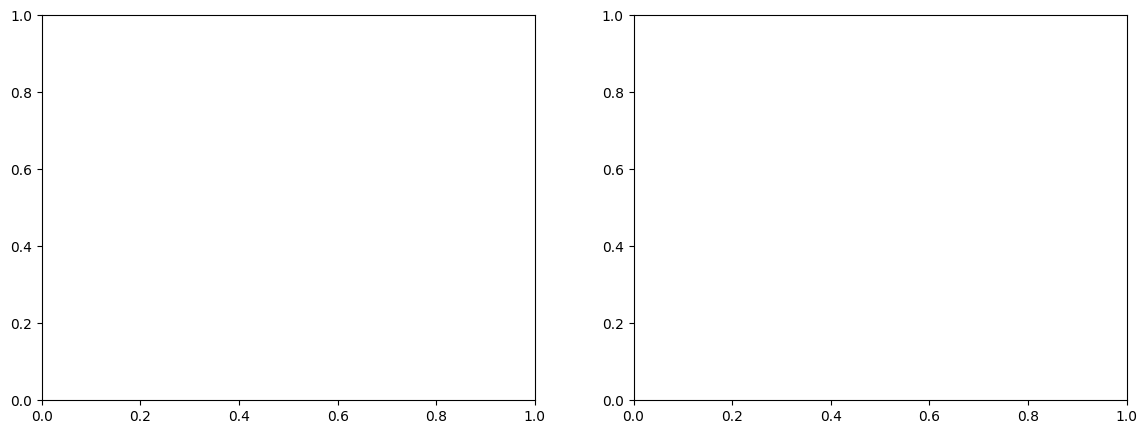

In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(final_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(final_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'{MODEL_TYPE.upper()} - Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(final_history.history['loss'], label='Train Loss')
axes[1].plot(final_history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'{MODEL_TYPE.upper()} - Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{MODEL_TYPE}_training_history.png', dpi=100)
plt.show()

print("✅ Training history plot saved!")

# Plot hyperparameter comparison (only if grid search was done)
if results_df is not None:
    print("\n📊 Hyperparameter Analysis:")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Learning rate
    lr_results = results_df.groupby('learning_rate')['val_accuracy'].mean()
    axes[0, 0].bar(lr_results.index, lr_results.values)
    axes[0, 0].set_xlabel('Learning Rate')
    axes[0, 0].set_ylabel('Avg Validation Accuracy')
    axes[0, 0].set_title('Impact: Learning Rate')
    axes[0, 0].grid(True, alpha=0.3)

    # Batch size
    batch_results = results_df.groupby('batch_size')['val_accuracy'].mean()
    axes[0, 1].bar(batch_results.index, batch_results.values)
    axes[0, 1].set_xlabel('Batch Size')
    axes[0, 1].set_ylabel('Avg Validation Accuracy')
    axes[0, 1].set_title('Impact: Batch Size')
    axes[0, 1].grid(True, alpha=0.3)

    # Optimizer
    opt_results = results_df.groupby('optimizer')['val_accuracy'].mean()
    axes[1, 0].bar(opt_results.index, opt_results.values)
    axes[1, 0].set_xlabel('Optimizer')
    axes[1, 0].set_ylabel('Avg Validation Accuracy')
    axes[1, 0].set_title('Impact: Optimizer')
    axes[1, 0].grid(True, alpha=0.3)

    # Epochs
    epoch_results = results_df.groupby('epochs')['val_accuracy'].mean()
    axes[1, 1].bar(epoch_results.index, epoch_results.values)
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Avg Validation Accuracy')
    axes[1, 1].set_title('Impact: Epochs')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{MODEL_TYPE}_hyperparameter_analysis.png', dpi=100)
    plt.show()
    print("✅ Hyperparameter analysis plot saved!")
else:
    print("\n📝 Skipped hyperparameter analysis (using quick start mode)")

## Step 10: Demo - Drowsiness Detection with Feedback System

In [9]:
# Initialize personalized manager for a student
# First, use the trained model from Step 7

# 🔧 FIX: Use the correct model file from Step 7
MODEL_TYPE = 'efficientnet'
trained_model_path = f"study_assistant_{MODEL_TYPE}_best.h5"

# Check if trained model exists
if not os.path.exists(trained_model_path):
    print(f"⚠️  Model not found: {trained_model_path}")
    print("Make sure you ran Step 7 (Quick Start training) first!")
    print(f"\nAvailable .h5 files:")
    for f in os.listdir('.'):
        if f.endswith('.h5'):
            print(f"  - {f}")
else:
    # Pass the trained model path explicitly to PersonalizedModelManager
    user_manager = PersonalizedModelManager('student_001', base_model_path=trained_model_path)

    print("\n" + "="*60)
    print("DEMO: Drowsiness Detection with Feedback System")
    print("="*60)

    print("\n📸 Scenario: Analyzing student image...")
    print("   (In real app, this would be from webcam)")

    # Make prediction (use actual image path)
    try:
        prediction = user_manager.predict('test.jpg')
        print(f"\n🤖 Model Prediction:")
        print(f"   Label: {prediction['label']}")
        print(f"   Confidence: {prediction['confidence']:.2%}")
        print(f"   Probabilities:")
        for label, prob in prediction['all_probabilities'].items():
            print(f"     - {label}: {prob:.2%}")

        # Check if alert should be sent
        should_alert = user_manager.should_send_break_alert(prediction)
        print(f"\n⚠️  Send break alert? {should_alert}")

        if should_alert:
            print("   💬 SYSTEM: Take a break! You seem drowsy.")
            print("\n👤 User Response Options:")
            print("   0 = I'm Alert")
            print("   1 = I'm Distracted")
            print("   2 = I'm Drowsy (confirm prediction)")
            
            # Simulated user feedback
            user_response = 0  # Example: user says they're alert
            print(f"\n   User chooses: {user_response} (Alert)")
            
            user_manager.process_feedback('test.jpg', user_response)
            
            # Show stats
            stats = user_manager.get_user_stats()
            print(f"\n📊 User Statistics:")
            if stats['feedback_stats']:
                print(f"   Total Feedback: {stats['feedback_stats']['total_feedback']}")
                print(f"   Model Accuracy: {stats['feedback_stats']['accuracy']:.1f}%")
                print(f"   Incorrect Predictions: {stats['feedback_stats']['incorrect_cases']}")

    except FileNotFoundError:
        print("\n⚠️  Note: test.jpg not found. This is just a demo.")
        print("In production, provide actual image path for real predictions.")

    print("\n✅ Demo completed!")

ValueError: No model config found in the file at user_models\student_001_model.h5.

## Step 11: Helper Functions for Production

In [ ]:
def get_or_create_user_manager(user_id):
    """Get existing user manager or create new one"""
    return PersonalizedModelManager(user_id)

def batch_process_feedback(user_id, feedback_data):
    """
    Process multiple feedback entries at once
    
    feedback_data format:
    [
        {'image_path': 'path/to/img1.jpg', 'user_feedback': 0},
        {'image_path': 'path/to/img2.jpg', 'user_feedback': 2},
        ...
    ]
    """
    manager = PersonalizedModelManager(user_id)
    
    for item in feedback_data:
        manager.process_feedback(item['image_path'], item['user_feedback'])
    
    return manager.get_user_stats()

def compare_user_models(user_id):
    """Compare user's personalized model with base model"""
    manager = PersonalizedModelManager(user_id)
    
    print(f"\n📊 Model Comparison for user {user_id}:")
    print("="*50)
    
    stats = manager.get_user_stats()
    print(f"Personalized Model Path: {stats['model_path']}")
    
    if stats['feedback_stats']:
        print(f"\nFeedback-based Accuracy: {stats['feedback_stats']['accuracy']:.1f}%")
        print(f"Total Feedback Samples: {stats['feedback_stats']['total_feedback']}")
    else:
        print("No feedback data available yet")
    
    return stats

def export_user_feedback(user_id, output_format='json'):
    """Export user feedback for analysis"""
    manager = PersonalizedModelManager(user_id)
    
    if output_format == 'json':
        output_path = os.path.join(FEEDBACK_LOG_DIR, f"{user_id}_export.json")
        with open(output_path, 'w') as f:
            json.dump(manager.user_feedback.feedback_log, f, indent=2)
        print(f"✅ Feedback exported to {output_path}")
        return output_path

print("✅ Production helper functions defined!")

## Summary

### Model Comparison

| Model | Best For | Speed | Accuracy |
|-------|----------|-------|----------|
| **EfficientNet** | Production/Real-time | ⚡ Fast | ⭐⭐⭐⭐ |
| **MobileNet** | Mobile/Edge devices | ⚡⚡ Very Fast | ⭐⭐⭐ |
| **ResNet** | Strong baseline | ⚡ Medium | ⭐⭐⭐⭐ |
| **InceptionV3** | Complex features | ⚡ Slow | ⭐⭐⭐⭐⭐ |

### Classes
- **0 = Alert**: Student is attentive
- **1 = Distracted**: Student seems distracted
- **2 = Drowsy**: Student shows drowsiness (yawning, etc.)

### Features
✅ Advanced deep learning models with transfer learning
✅ Hyperparameter grid search for optimization
✅ User feedback system for continuous improvement
✅ Personalized models that learn individual patterns
✅ Reinforcement learning from user corrections